# House Price Prediction — Experiment 1

Baseline: all engineered numeric and categorical features; MLP 64-32.


In [1]:
EXPERIMENT_NAME = "exp1"
EXPERIMENT_DESCRIPTION = 'Baseline: all engineered numeric and categorical features; MLP 64-32.'
print(EXPERIMENT_NAME, EXPERIMENT_DESCRIPTION)


exp1 Baseline: all engineered numeric and categorical features; MLP 64-32.


In [2]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

SEED = 42
np.random.seed(SEED)

DATA_PATH = Path(
    "data/house_prices.csv"
)

MODEL_DIR = Path("models")
FIGURE_DIR = Path("figures")
OUTPUT_DIR = Path("outputs")

MODEL_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.columns.tolist())

display(df.head())

print(df.isna().mean().sort_values(
    ascending=False
))

(187531, 21)
['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Title                0.000000
location             0.000000
Amount(in rupees)    0.000000
Index                0.000000
dtype: float64


In [4]:
def parse_amount(value):

    if pd.isna(value):
        return np.nan

    if isinstance(
        value,
        (int, float)
    ):
        return float(value)

    text = (
        str(value)
        .lower()
        .replace(",", "")
        .replace("₹", "")
        .strip()
    )

    match = re.search(
        r"\d+(?:\.\d+)?",
        text
    )

    if match is None:
        return np.nan

    number = float(
        match.group()
    )

    if (
        "crore" in text
        or "cr" in text
    ):
        return number * 10_000_000

    if (
        "lakh" in text
        or "lac" in text
    ):
        return number * 100_000

    return number

df["price_clean"] = (
    df["Amount(in rupees)"]
    .apply(parse_amount)
)

print(
    df["price_clean"].describe()
)

df = df[
    df["price_clean"].notna()
].copy()

df = df[
    df["price_clean"] > 0
].copy()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64


In [5]:
def parse_area_sqft(value):

    if pd.isna(value):
        return np.nan

    text = (
        str(value)
        .lower()
        .replace(",", "")
        .strip()
    )

    match = re.search(
        r"\d+(?:\.\d+)?",
        text
    )

    if match is None:
        return np.nan

    number = float(
        match.group()
    )

    if (
        "sqft" in text
        or "sq ft" in text
    ):
        return number

    if (
        "sqm" in text
        or "sq m" in text
    ):
        return number * 10.7639

    if (
        "sqyrd" in text
        or "sq yard" in text
    ):
        return number * 9.0

    if "acre" in text:
        return number * 43560

    return np.nan


df["carpet_sqft"] = (
    df["Carpet Area"]
    .apply(parse_area_sqft)
)

In [6]:
def parse_floor(value):

    if pd.isna(value):
        return (
            np.nan,
            np.nan
        )

    text = str(value).lower()

    if "ground" in text:
        current = 0
    else:
        numbers = re.findall(
            r"\d+",
            text
        )

        current = (
            float(numbers[0])
            if len(numbers) >= 1
            else np.nan
        )

    numbers = re.findall(
        r"\d+",
        text
    )

    total = (
        float(numbers[-1])
        if len(numbers) >= 2
        else np.nan
    )

    return (
        current,
        total
    )

floor_values = (
    df["Floor"]
    .apply(parse_floor)
)

df["floor_num"] = [
    x[0]
    for x in floor_values
]

df["total_floors"] = [
    x[1]
    for x in floor_values
]

In [7]:
numeric_cols = [
    "carpet_sqft",
    "Bathroom",
    "Balcony",
    "floor_num",
    "total_floors"
]

for col in [
    "Bathroom",
    "Balcony"
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )



In [8]:
categorical_cols = [
    "Status",
    "Transaction",
    "Furnishing",
    "facing",
    "Ownership",
    "location"
]

In [9]:
n = len(df)

rng = np.random.default_rng(
    SEED
)

indices = rng.permutation(n)

n_train = int(
    0.70 * n
)

n_val = int(
    0.15 * n
)

train_idx = indices[
    :n_train
]

val_idx = indices[
    n_train:
    n_train + n_val
]

test_idx = indices[
    n_train + n_val:
]

train_df = (
    df.iloc[train_idx]
    .reset_index(drop=True)
)

val_df = (
    df.iloc[val_idx]
    .reset_index(drop=True)
)

test_df = (
    df.iloc[test_idx]
    .reset_index(drop=True)
)

In [10]:
X_train_num = (
    train_df[numeric_cols]
    .to_numpy(
        dtype=np.float32
    )
)

X_val_num = (
    val_df[numeric_cols]
    .to_numpy(
        dtype=np.float32
    )
)

X_test_num = (
    test_df[numeric_cols]
    .to_numpy(
        dtype=np.float32
    )
)

num_median = np.nanmedian(
    X_train_num,
    axis=0,
    keepdims=True
)

X_train_num = np.where(
    np.isnan(X_train_num),
    num_median,
    X_train_num
)

X_val_num = np.where(
    np.isnan(X_val_num),
    num_median,
    X_val_num
)

X_test_num = np.where(
    np.isnan(X_test_num),
    num_median,
    X_test_num
)

num_mean = X_train_num.mean(
    axis=0,
    keepdims=True
)

num_std = X_train_num.std(
    axis=0,
    keepdims=True
)

num_std = np.where(
    num_std < 1e-8,
    1.0,
    num_std
)

X_train_num = (
    X_train_num - num_mean
) / num_std

X_val_num = (
    X_val_num - num_mean
) / num_std

X_test_num = (
    X_test_num - num_mean
) / num_std

In [11]:
def fit_category_maps(
    train_df,
    categorical_cols
):

    maps = {}

    for col in categorical_cols:

        values = (
            train_df[col]
            .fillna("__MISSING__")
            .astype(str)
        )

        if col == "Location":
            max_categories = 50
        else:
            max_categories = 20

        categories = (
            values
            .value_counts()
            .head(max_categories)
            .index
            .tolist()
        )

        maps[col] = categories

    return maps

category_maps = fit_category_maps(
    train_df,
    categorical_cols
)

def transform_categories(
    df,
    category_maps
):

    matrices = []

    for col, categories in (
        category_maps.items()
    ):

        values = (
            df[col]
            .fillna("__MISSING__")
            .astype(str)
            .to_numpy()
        )

        lookup = {
            value: i
            for i, value
            in enumerate(categories)
        }

        other_index = len(
            categories
        )

        X_col = np.zeros(
            (
                len(df),
                len(categories) + 1
            ),
            dtype=np.float32
        )

        for i, value in enumerate(
            values
        ):

            idx = lookup.get(
                value,
                other_index
            )

            X_col[i, idx] = 1.0

        matrices.append(
            X_col
        )

    return np.concatenate(
        matrices,
        axis=1
    )

X_train_cat = transform_categories(
    train_df,
    category_maps
)

X_val_cat = transform_categories(
    val_df,
    category_maps
)

X_test_cat = transform_categories(
    test_df,
    category_maps
)

X_train = np.concatenate(
    [
        X_train_num,
        X_train_cat
    ],
    axis=1
)

X_val = np.concatenate(
    [
        X_val_num,
        X_val_cat
    ],
    axis=1
)

X_test = np.concatenate(
    [
        X_test_num,
        X_test_cat
    ],
    axis=1
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(124492, 56)
(26677, 56)
(26678, 56)


In [12]:
y_train_raw = (
    train_df["price_clean"]
    .to_numpy(dtype=np.float32)
)

y_val_raw = (
    val_df["price_clean"]
    .to_numpy(dtype=np.float32)
)

y_test_raw = (
    test_df["price_clean"]
    .to_numpy(dtype=np.float32)
)

y_train_log = np.log1p(
    y_train_raw
)

y_val_log = np.log1p(
    y_val_raw
)

y_test_log = np.log1p(
    y_test_raw
)

y_mean = y_train_log.mean()
y_std = y_train_log.std()

y_train = (
    (
        y_train_log - y_mean
    )
    /
    y_std
).reshape(-1, 1)

y_val = (
    (
        y_val_log - y_mean
    )
    /
    y_std
).reshape(-1, 1)

y_test = (
    (
        y_test_log - y_mean
    )
    /
    y_std
).reshape(-1, 1)

In [13]:
def initialize_parameters(
    input_dim,
    hidden1=64,
    hidden2=32,
    output_dim=1,
    seed=42
):

    rng = np.random.default_rng(seed)

    W1 = (
        rng.standard_normal(
            (input_dim, hidden1)
        )
        *
        np.sqrt(
            2 / input_dim
        )
    ).astype(np.float32)

    b1 = np.zeros(
        (1, hidden1),
        dtype=np.float32
    )

    W2 = (
        rng.standard_normal(
            (hidden1, hidden2)
        )
        *
        np.sqrt(
            2 / hidden1
        )
    ).astype(np.float32)

    b2 = np.zeros(
        (1, hidden2),
        dtype=np.float32
    )

    W3 = (
        rng.standard_normal(
            (hidden2, 1)
        )
        *
        np.sqrt(
            2 / hidden2
        )
    ).astype(np.float32)

    b3 = np.zeros(
        (1, 1),
        dtype=np.float32
    )

    return {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2,
        "W3": W3,
        "b3": b3
    }

In [14]:
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(np.float32)

In [15]:
def forward(X, params):

    z1 = (
        X @ params["W1"]
        + params["b1"]
    )

    h1 = relu(z1)

    z2 = (
        h1 @ params["W2"]
        + params["b2"]
    )

    h2 = relu(z2)

    z3 = (
        h2 @ params["W3"]
        + params["b3"]
    )

    prediction = z3

    cache = {
        "X": X,
        "z1": z1,
        "h1": h1,
        "z2": z2,
        "h2": h2,
        "prediction": prediction
    }

    return prediction, cache

In [16]:
def mse_loss(
    prediction,
    y
):

    return np.mean(
        (
            prediction - y
        ) ** 2
    )

In [17]:
def backward(
    y,
    params,
    cache
):

    X = cache["X"]

    z1 = cache["z1"]
    h1 = cache["h1"]

    z2 = cache["z2"]
    h2 = cache["h2"]

    prediction = cache[
        "prediction"
    ]

    n = len(y)

    dz3 = (
        2.0
        *
        (
            prediction - y
        )
        /
        n
    )

    dW3 = h2.T @ dz3

    db3 = np.sum(
        dz3,
        axis=0,
        keepdims=True
    )

    dh2 = (
        dz3
        @
        params["W3"].T
    )

    dz2 = (
        dh2
        *
        relu_derivative(z2)
    )

    dW2 = h1.T @ dz2

    db2 = np.sum(
        dz2,
        axis=0,
        keepdims=True
    )

    dh1 = (
        dz2
        @
        params["W2"].T
    )

    dz1 = (
        dh1
        *
        relu_derivative(z1)
    )

    dW1 = X.T @ dz1

    db1 = np.sum(
        dz1,
        axis=0,
        keepdims=True
    )

    return {
        "W1": dW1,
        "b1": db1,
        "W2": dW2,
        "b2": db2,
        "W3": dW3,
        "b3": db3
    }

In [18]:
def update_parameters(
    params,
    grads,
    learning_rate
):

    for key in params:

        params[key] -= (
            learning_rate
            *
            grads[key]
        )

In [19]:
params = initialize_parameters(
    input_dim=X_train.shape[1],
    seed=SEED
)

learning_rate = 0.001
epochs = 25
batch_size = 1024

rng = np.random.default_rng(
    SEED
)

train_loss_history = []
val_loss_history = []

for epoch in range(epochs):

    indices = rng.permutation(
        len(X_train)
    )

    for start in range(
        0,
        len(X_train),
        batch_size
    ):

        batch_idx = indices[
            start:
            start + batch_size
        ]

        X_batch = X_train[
            batch_idx
        ]

        y_batch = y_train[
            batch_idx
        ]

        prediction, cache = forward(
            X_batch,
            params
        )

        grads = backward(
            y_batch,
            params,
            cache
        )

        update_parameters(
            params,
            grads,
            learning_rate
        )

    train_prediction, _ = forward(
        X_train,
        params
    )

    val_prediction, _ = forward(
        X_val,
        params
    )

    train_loss = mse_loss(
        train_prediction,
        y_train
    )

    val_loss = mse_loss(
        val_prediction,
        y_val
    )

    train_loss_history.append(
        train_loss
    )

    val_loss_history.append(
        val_loss
    )

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.5f} | "
        f"Val Loss: {val_loss:.5f}"
    )

Epoch 01 | Train Loss: 0.76691 | Val Loss: 0.76385
Epoch 02 | Train Loss: 0.60095 | Val Loss: 0.59975
Epoch 03 | Train Loss: 0.53113 | Val Loss: 0.53117
Epoch 04 | Train Loss: 0.49152 | Val Loss: 0.49208
Epoch 05 | Train Loss: 0.46452 | Val Loss: 0.46532
Epoch 06 | Train Loss: 0.44478 | Val Loss: 0.44562
Epoch 07 | Train Loss: 0.42961 | Val Loss: 0.43045
Epoch 08 | Train Loss: 0.41735 | Val Loss: 0.41812
Epoch 09 | Train Loss: 0.40699 | Val Loss: 0.40769
Epoch 10 | Train Loss: 0.39821 | Val Loss: 0.39884
Epoch 11 | Train Loss: 0.39063 | Val Loss: 0.39118
Epoch 12 | Train Loss: 0.38391 | Val Loss: 0.38438
Epoch 13 | Train Loss: 0.37794 | Val Loss: 0.37836
Epoch 14 | Train Loss: 0.37254 | Val Loss: 0.37291
Epoch 15 | Train Loss: 0.36750 | Val Loss: 0.36781
Epoch 16 | Train Loss: 0.36281 | Val Loss: 0.36307
Epoch 17 | Train Loss: 0.35853 | Val Loss: 0.35873
Epoch 18 | Train Loss: 0.35448 | Val Loss: 0.35461
Epoch 19 | Train Loss: 0.35065 | Val Loss: 0.35070
Epoch 20 | Train Loss: 0.34700 

In [20]:
test_pred_scaled, _ = forward(
    X_test,
    params
)

pred_log = (
    test_pred_scaled.ravel()
    *
    y_std
    +
    y_mean
)

pred_price = np.expm1(
    pred_log
)

pred_price = np.maximum(
    pred_price,
    0
)

In [21]:
def mae(y_true, y_pred):

    return np.mean(
        np.abs(
            y_true - y_pred
        )
    )


def rmse(y_true, y_pred):

    return np.sqrt(
        np.mean(
            (
                y_true - y_pred
            ) ** 2
        )
    )


def r2_score(y_true, y_pred):

    ss_res = np.sum(
        (
            y_true - y_pred
        ) ** 2
    )

    ss_tot = np.sum(
        (
            y_true
            -
            np.mean(y_true)
        ) ** 2
    )

    return (
        1
        -
        ss_res / ss_tot
    )

test_mae = mae(
    y_test_raw,
    pred_price
)

test_rmse = rmse(
    y_test_raw,
    pred_price
)

test_r2 = r2_score(
    y_test_raw,
    pred_price
)

print(
    f"MAE  : {test_mae:,.0f} ₹"
)

print(
    f"RMSE : {test_rmse:,.0f} ₹"
)

print(
    f"R²   : {test_r2:.4f}"
)

MAE  : 4,446,476 ₹
RMSE : 10,787,093 ₹
R²   : 0.4626


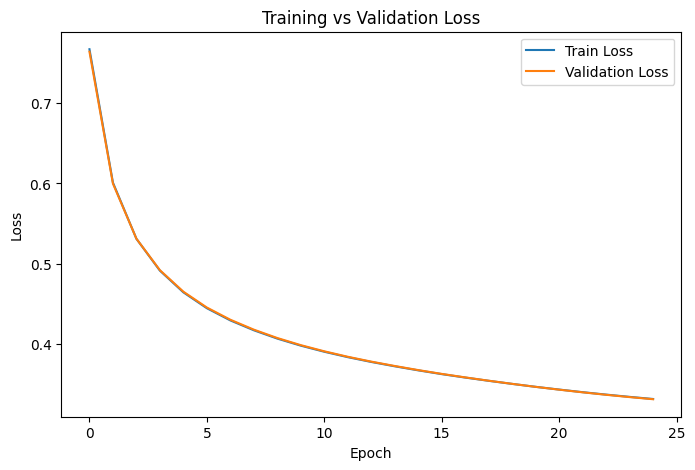

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_loss_history,
    label="Train Loss"
)

plt.plot(
    val_loss_history,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.show()

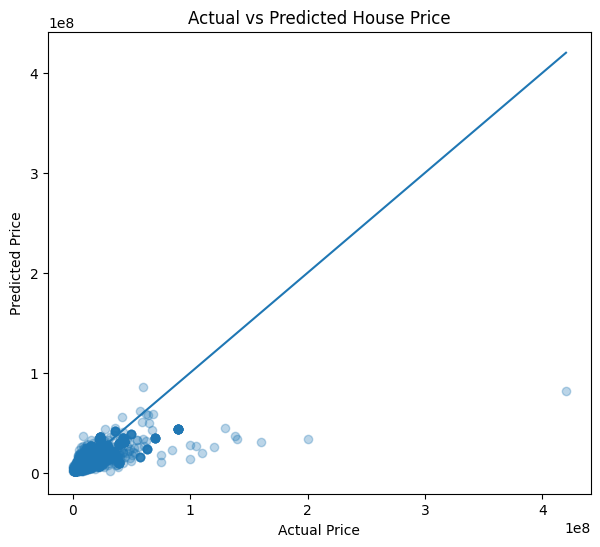

In [23]:
sample_size = min(
    5000,
    len(y_test_raw)
)

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_raw[:sample_size],
    pred_price[:sample_size],
    alpha=0.3
)

min_price = min(
    y_test_raw[:sample_size].min(),
    pred_price[:sample_size].min()
)

max_price = max(
    y_test_raw[:sample_size].max(),
    pred_price[:sample_size].max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted House Price"
)

plt.show()

In [24]:
# Phần tiếp theo là lưu model và vẽ biểu đồ

In [25]:
HOUSE_MODEL_PATH = (
    MODEL_DIR
    /
    "house_price_numpy_mlp-exp1.npz"
)

np.savez(
    HOUSE_MODEL_PATH,

    # Neural Network
    W1=params["W1"],
    b1=params["b1"],

    W2=params["W2"],
    b2=params["b2"],

    W3=params["W3"],
    b3=params["b3"],

    # Numeric preprocessing
    num_median=num_median,
    num_mean=num_mean,
    num_std=num_std,

    # Target preprocessing
    y_mean=np.array(
        [y_mean],
        dtype=np.float32
    ),

    y_std=np.array(
        [y_std],
        dtype=np.float32
    ),

    # Feature names
    numeric_cols=np.asarray(
        numeric_cols,
        dtype=str
    ),

    categorical_cols=np.asarray(
        categorical_cols,
        dtype=str
    )
)

print(
    "Saved model:",
    HOUSE_MODEL_PATH
)

Saved model: models\house_price_numpy_mlp-exp1.npz


In [26]:
import json
CATEGORY_MAP_PATH = (
    MODEL_DIR
    /
    "house_price_category_maps-exp1.json"
)

category_maps_to_save = {
    str(col): [
        str(value)
        for value in categories
    ]
    for col, categories
    in category_maps.items()
}

with open(
    CATEGORY_MAP_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        category_maps_to_save,
        f,
        ensure_ascii=False,
        indent=2
    )

print(
    "Saved category maps:",
    CATEGORY_MAP_PATH
)

Saved category maps: models\house_price_category_maps-exp1.json


In [27]:
saved = np.load(
    HOUSE_MODEL_PATH
)

loaded_params = {
    "W1": saved["W1"],
    "b1": saved["b1"],

    "W2": saved["W2"],
    "b2": saved["b2"],

    "W3": saved["W3"],
    "b3": saved["b3"]
}

loaded_num_median = saved[
    "num_median"
]

loaded_num_mean = saved[
    "num_mean"
]

loaded_num_std = saved[
    "num_std"
]

loaded_y_mean = float(
    saved["y_mean"][0]
)

loaded_y_std = float(
    saved["y_std"][0]
)

loaded_numeric_cols = (
    saved["numeric_cols"]
)

loaded_categorical_cols = (
    saved["categorical_cols"]
)

with open(
    CATEGORY_MAP_PATH,
    "r",
    encoding="utf-8"
) as f:

    loaded_category_maps = (
        json.load(f)
    )

print(
    "House Price model loaded successfully."
)

print(
    "W1:",
    loaded_params["W1"].shape
)

print(
    "Numeric features:",
    loaded_numeric_cols
)

print(
    "Categorical features:",
    loaded_categorical_cols
)

House Price model loaded successfully.
W1: (56, 64)
Numeric features: ['carpet_sqft' 'Bathroom' 'Balcony' 'floor_num' 'total_floors']
Categorical features: ['Status' 'Transaction' 'Furnishing' 'facing' 'Ownership' 'location']


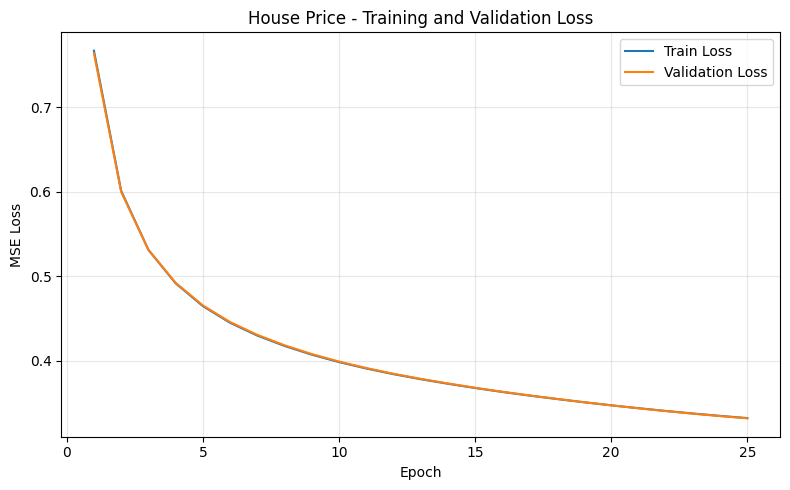

In [28]:
plt.figure(
    figsize=(8, 5)
)

epochs_axis = np.arange(
    1,
    len(train_loss_history) + 1
)

plt.plot(
    epochs_axis,
    train_loss_history,
    label="Train Loss"
)

plt.plot(
    epochs_axis,
    val_loss_history,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "House Price - Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

HOUSE_LOSS_PATH = (
    FIGURE_DIR
    /
    "house_price_loss_curve-exp1.png"
)

plt.savefig(
    HOUSE_LOSS_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
test_pred_scaled, _ = forward(
    X_test,
    params
)

pred_log = (
    test_pred_scaled.ravel()
    *
    y_std
    +
    y_mean
)

pred_price = np.expm1(
    pred_log
)

pred_price = np.maximum(
    pred_price,
    0
)

test_mae = mae(
    y_test_raw,
    pred_price
)

test_rmse = rmse(
    y_test_raw,
    pred_price
)

test_r2 = r2_score(
    y_test_raw,
    pred_price
)

print(
    f"MAE  : ₹{test_mae:,.0f}"
)

print(
    f"RMSE : ₹{test_rmse:,.0f}"
)

print(
    f"R²   : {test_r2:.4f}"
)

MAE  : ₹4,446,476
RMSE : ₹10,787,093
R²   : 0.4626


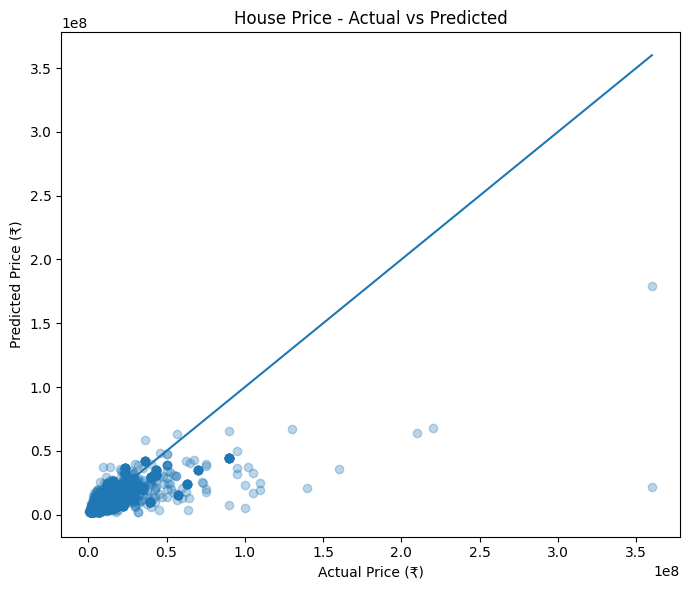

In [30]:
rng_plot = np.random.default_rng(
    SEED
)

sample_size = min(
    5000,
    len(y_test_raw)
)

sample_indices = (
    rng_plot.choice(
        len(y_test_raw),
        size=sample_size,
        replace=False
    )
)

actual_sample = (
    y_test_raw[
        sample_indices
    ]
)

pred_sample = (
    pred_price[
        sample_indices
    ]
)

plt.figure(
    figsize=(7, 6)
)

plt.scatter(
    actual_sample,
    pred_sample,
    alpha=0.3
)

min_value = min(
    actual_sample.min(),
    pred_sample.min()
)

max_value = max(
    actual_sample.max(),
    pred_sample.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel(
    "Actual Price (₹)"
)

plt.ylabel(
    "Predicted Price (₹)"
)

plt.title(
    "House Price - Actual vs Predicted"
)

plt.tight_layout()

ACTUAL_PRED_PATH = (
    FIGURE_DIR
    /
    "house_price_actual_vs_predicted-exp1.png"
)

plt.savefig(
    ACTUAL_PRED_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

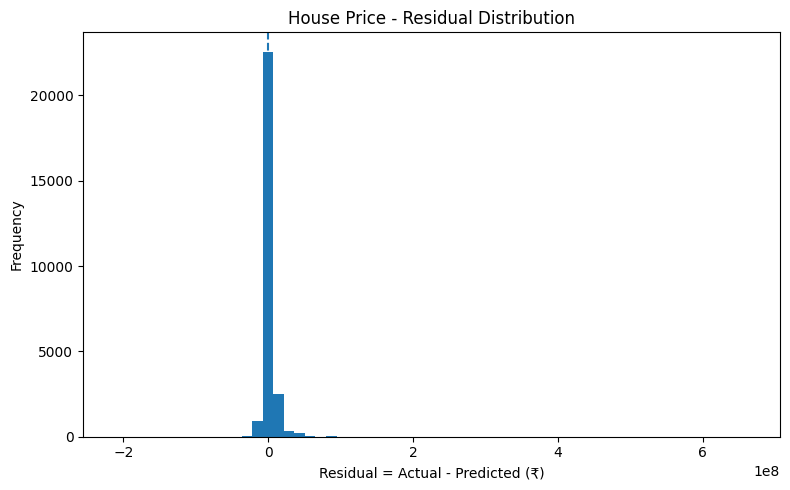

In [31]:
residuals = (
    y_test_raw
    -
    pred_price
)

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    residuals,
    bins=60
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Residual = Actual - Predicted (₹)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "House Price - Residual Distribution"
)

plt.tight_layout()

RESIDUAL_DIST_PATH = (
    FIGURE_DIR
    /
    "house_price_residual_distribution-exp1.png"
)

plt.savefig(
    RESIDUAL_DIST_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

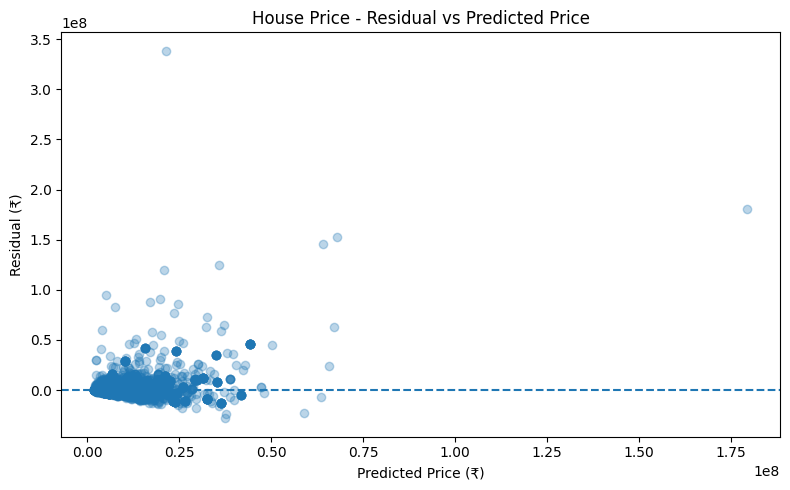

In [32]:
plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    pred_sample,
    residuals[
        sample_indices
    ],
    alpha=0.3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Price (₹)"
)

plt.ylabel(
    "Residual (₹)"
)

plt.title(
    "House Price - Residual vs Predicted Price"
)

plt.tight_layout()

RESIDUAL_PRED_PATH = (
    FIGURE_DIR
    /
    "house_price_residual_vs_predicted-exp1.png"
)

plt.savefig(
    RESIDUAL_PRED_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
house_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2"
    ],

    "Value": [
        test_mae,
        test_rmse,
        test_r2
    ]
})

HOUSE_METRICS_PATH = (
    OUTPUT_DIR
    /
    "house_price_metrics-exp1.csv"
)

house_metrics.to_csv(
    HOUSE_METRICS_PATH,
    index=False
)

display(
    house_metrics
)

,Metric,Value
0,MAE,4.446476e+06
1,RMSE,1.078709e+07
2,R2,4.625837e-01


In [34]:
experiment_config = {
    "experiment": "exp1",
    "description": EXPERIMENT_DESCRIPTION,
    "numeric_features": list(numeric_cols),
    "categorical_features": list(categorical_cols),
    "feature_selection": False,
    "learning_rate": learning_rate,
    "epochs": epochs,
    "batch_size": batch_size,
    "test_mae": float(test_mae),
    "test_rmse": float(test_rmse),
    "test_r2": float(test_r2),
}
with open(OUTPUT_DIR / "house_price_config-exp1.json", "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, ensure_ascii=False, indent=2)
print("Saved experiment config:", experiment_config)


Saved experiment config: {'experiment': 'exp1', 'description': 'Baseline: all engineered numeric and categorical features; MLP 64-32.', 'numeric_features': ['carpet_sqft', 'Bathroom', 'Balcony', 'floor_num', 'total_floors'], 'categorical_features': ['Status', 'Transaction', 'Furnishing', 'facing', 'Ownership', 'location'], 'feature_selection': False, 'learning_rate': 0.001, 'epochs': 25, 'batch_size': 1024, 'test_mae': 4446476.5, 'test_rmse': 10787093.0, 'test_r2': 0.4625837206840515}
